In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [2]:
import utils.config as config
importlib.reload(config)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *

In [3]:
# network_dir = f'{network_path}'
# network_dir = '../../data/networks/output_dye_trace/8'
network_dir = '../../data/networks/single_conduit'
nodes = pd.read_csv(f'{network_dir}/nodes_simplified.csv')
nodes['id'] = nodes.id.astype(int)
edges = pd.read_csv(f'{network_dir}/edges_simplified.csv')
# network = np.load(f'{network_dir}/network.npy')

In [4]:
edges['y_0'] = nodes.iloc[edges.from_id].reset_index().y
edges['y_1'] = nodes.iloc[edges.to_id].reset_index().y
edges['x_0'] = nodes.iloc[edges.from_id].reset_index().x
edges['x_1'] = nodes.iloc[edges.to_id].reset_index().x
edges['z_0'] = nodes.iloc[edges.from_id].reset_index().z
edges['z_1'] = nodes.iloc[edges.to_id].reset_index().z

In [5]:
import plotly.graph_objects as go
lines = edges[["x_0", "y_0", "z_0", "x_1", "y_1", "z_1"]].values
lines = lines.reshape(-1, 2, 3)
line_traces = []
for line in lines:
    line_traces.append(
        go.Scatter3d(
            x=line[:,0],
            y=line[:,1],
            z=line[:,2],
            mode='lines',
            line=dict(color='blue', width=1),
            showlegend=False
        )
    )
node_type_map = {cat: i for i, cat in enumerate(nodes.type.unique())}
node_type_map = {i : i for i in nodes.id}
node_colors = nodes.type.map(node_type_map)
# Scatter for nodes
scatter = go.Scatter3d(
    x=nodes.x,
    y=nodes.y,
    z=nodes.z,
    mode='markers',
    marker=dict(
        size=5,
        color=node_colors,  # categorical or numeric
        colorscale='Viridis',
        showscale=True
    )
)

# Combine and plot
fig = go.Figure(data=line_traces + [scatter])
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [27]:
loader = cdl.CaveDataLoader(nodes = nodes, edges = edges )
geometry = loader.load_cave_data(d = 1)
inlets, outlets = loader.extract_boundary_nodes()
diffuse_inlets =  [node for node in nodes.id if (node not in outlets) and (node not in inlets)]
# inlets += [node for node in nodes.id if (node not in outlets) and (node%4==0)]
# inlets = [node for node in nodes.id if node not in outlets]
print(f'Inlets: {inlets}, outlets: {outlets}, diffuse inlets: {len(diffuse_inlets)}')

Inlets: [0], outlets: [58], diffuse inlets: 57


In [28]:
time_start = pd.to_datetime('2018-05-02')
time_end = pd.to_datetime('2018-06-14')
rech = convert_df_to_datetime(pd.read_csv('recharge/conduit_recharge_S_max_1_k_0.1_n_0.1_theta_0.0_alpha_l_0.14_alpha_h_0.4.csv'), 'date')
rech['R_h (m3/s)'] = rech['R_h'] / 86400  #convert to m^3/s
rech['R_o (m3/s)'] = rech['Q_l'] / 86400
rech_limited_range = rech[(rech['date'] >= time_start) & (rech['date'] <= time_end)].reset_index(drop=True)
rech_limited_range['R_h_per_inlet'] = rech_limited_range['R_h (m3/s)'] / len(inlets)
rech_limited_range['R_o_per_inlet'] = rech_limited_range['R_o (m3/s)'] / len(diffuse_inlets)
rech_limited_range['time (s)'] = (rech_limited_range['date'] - rech_limited_range['date'][0]).dt.total_seconds()
ss_rech_per_inlet = 0.029 / len(diffuse_inlets)  # m3/s

<Axes: xlabel='time (s)', ylabel='R_o_per_inlet'>

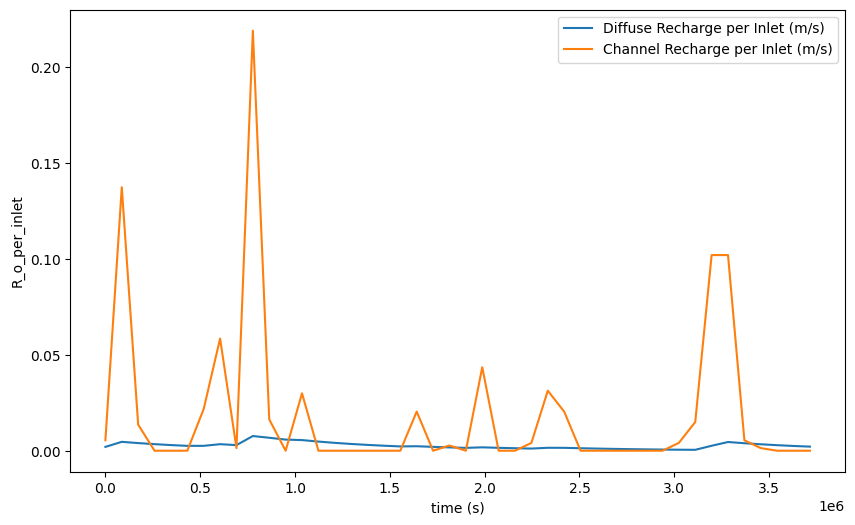

In [8]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x= rech_limited_range['time (s)'], y= rech_limited_range['R_o_per_inlet'], label='Diffuse Recharge per Inlet (m/s)', ax=ax)
sns.lineplot(x= rech_limited_range['time (s)'], y= rech_limited_range['R_h_per_inlet'], label='Channel Recharge per Inlet (m/s)', ax=ax)

In [9]:
def main(geometry, base_dir = '.', inlets = [], outlets = [], cn_params = None, flowrate = None, water_depth = None, inflow_boundary = {}, head_boundary ={}, steady_state = True, t_max = 1000, dt = 1, inflow_type = 'constant', head_type = 'constant', end_time = 3600, **params):
    
    # base_dir = os.path.dirname(os.path.abspath(__file__))
    adaptive_timesteps = params.get('adaptive_timesteps', True)
    # Setup flow simulation parameters
    physical_properties = {
        'water_density': 1000,        # kg/m^3
        'gravity': 9.81,              # m/s^2
        'dynamic_viscosity': 0.001,   # Pa.s (kg/m.s)
        'geometry_channel': False,    # Channel geometry for analytical solutions (Default False)
        'channel_type': 'infinite',   # 'infinite' for infinitely wide channel, 'finite' for defined width
        'channel_width': 1.0,         # Width of the channel (only used if channel_type is 'finite')
    }
    
    solver_settings = {
        'relaxation_factor': 0.6,    # Dimensionless
        'max_iterations': 20,        # Maximum Picard iterations
        'picard_depth_tol': 1e-5,    # Picard depth tolerance (meters)
        'ss_rel_l2tol': 1e-3,         # L2 tolerance for steady-state
        'ss_rel_madtol': 1e-8         # Median tolerance for steady-state
    }
    
    simulation_settings = {
        'min_waterdepth': 1e-10,      # Minimum water depth (meters)
        'min_flowrate': 1e-10,        # Minimum flow rate (m^3/s)
        'courant': 0.8,               # Courant number
        'adaptive_timesteps': adaptive_timesteps,   # Use adaptive timestepping
        'dt_init': dt,             # Initial (or constant) timestep (seconds)
        'dt_max': params.get('dt_max', 1.0),                # Maximum allowable time step
        'steady_state': steady_state,         # Steady-state (True) or transient (False)
        't_max': t_max,              # Maximum time for transient simulations (seconds)
        'print_info_interval': 1000,     # Print info every # time steps
    }
    
    output_settings = {
        'output_interval': 10.0,
        'time': True,
        'time_step_size': True,
        'flowrates': True,
        'water_depths': True,
        'l2_norms': True,
        'convergence_fails': True,
        'reynolds_numbers': True,
    }
    
    logging_settings = {
        'base_dir': base_dir,
        'log_file': 'simulation.log'
    }
    
    # Create network object using OpenPNM
    dl = 1 # Constant spacing between nodes (meters)
    cn_geometry = geometry
    
    # Compute conduit lengths using the utility function
    cn_geometry = compute_conduit_lengths(cn_geometry)
    
    # Assign conduit properties
    for param, val in cn_params.items():
        print(param)
        cn_geometry[param] = val

    # Create flow network object
    flow_network = FlowSimulation(cn_geometry,
                                  physical_properties = physical_properties,
                                  solver_settings = solver_settings,
                                  simulation_settings = simulation_settings,
                                  logging_settings = logging_settings)
    
    # Set initial conditions
    if type(flowrate) is float:
        initial_Q = np.full(cn_geometry.Nt, flowrate, dtype=float)   # Initial flows at each conduit (Nt throats)
    elif type(flowrate) is np.ndarray: 
        initial_Q = flowrate #if initial conditions is passed as an array indexed by conduit id
    if type(water_depth) is float:
        initial_y = np.full(cn_geometry.Np, water_depth, dtype=float)  # Initial water depths at each node (Np pores)    
    elif type(water_depth) is np.ndarray:
        initial_y = water_depth #if initial conditions is passed as an array indexed by node id
    flow_network.set_initial_conditions(initial_Q, initial_y)
    
    # Set boundary conditions
    for n in inflow_boundary.keys():
        if inflow_type == 'ramp':
            inflow_values = ('ramp', inflow_boundary[n]['flow_start'], inflow_boundary[n]['time_start'], inflow_boundary[n]['flow_end'], inflow_boundary[n]['time_end'])
        elif inflow_type == 'timeseries':
            inflow_values = ('timeseries', inflow_boundary[n]['time'], inflow_boundary[n]['flow'])
        elif inflow_type == 'constant':
            inflow_values = inflow_boundary[n]['flow']
        flow_network.set_inflow_BC(nodes = list(n), values = inflow_values)

    for n in head_boundary.keys():
        if head_type == 'ramp':
            head_values = ('ramp', head_boundary[n]['head_start'], head_boundary[n]['time_start'], head_boundary[n]['head_end'], head_boundary[n]['time_end'])
        elif head_type == 'timeseries':
            head_values = ('timeseries', head_boundary[n]['time'], head_boundary[n]['head'])
        elif head_type == 'constant':
            head_values = head_boundary[n]['head']
        flow_network.set_waterdepth_BC(nodes = list(n), values = head_values)

    
    # flow_network.set_boundary_conditions(
    # inflow_boundary=inflow_boundary,
    # waterdepth_boundary=waterdepth_boundary,
    # inflow_type=inflow_type,
    # end_time= end_time)

    # Run simulation and store results
    results = flow_network.run_simulation(desired_outputs = output_settings)
    
    # Get arrays from results container
    Q_history = results['flowrates']
    y_history = results['water_depths']
    t_history = results['time']
    
    
    animation_settings = {
        'update_interval': 1,
        'conduit_plotradius': 0.5,
        'bar_plotradius': 0.5,
        'node_plotsize': 5,
        'depthscaling': 20,
        'fig_width': 1600,
        'fig_height': 800,
        'zoom_factor': 1.0,
        'background_color': 'black',
        'isometric_view': False,
        'create_animation': False,
        'filename': "network_animation2.mp4"
    }
    
    animate_network(cn_geometry=cn_geometry, 
                    Q_history=Q_history, 
                    y_history=y_history, 
                    t_history=t_history, 
                    **animation_settings)
    save_path = params.get("save_path")
    if save_path is not None:
        try:
            os.makedirs(save_path, exist_ok=False)
        except FileExistsError:
            print("Directory exists. Make sure you don't want to overwrite it.")
            pass
        input_data = {'nodes' : nodes, 'edges' : edges, 
                      'inlets': inlets,
                      'diffuse_inlets': diffuse_inlets,
                      'outlets': outlets,
                      'cn_geometry' : cn_geometry, 
                      'inflow_boundary' : inflow_boundary, 
                      'head_boundary' : head_boundary, 
                      'initial_depth' : water_depth, 
                      'initial_flowrate' : flowrate}
        with open(f'{save_path}/input_data.pkl', 'wb') as f:
            pickle.dump(input_data, f)
            print (f'results saved to {save_path}')    

        # Save large numeric arraylike data efficiently (easy to open and extract)
        Q = results['flowrates']
        y = results['water_depths']
        t = results['time']
        re = results['reynolds_numbers']
        np.savez_compressed(f'{save_path}/results_arrays.npz', Q=Q, y=y, t=t, re=re)
    return results

In [120]:
##ss spin up 
results = main(geometry, 
               inlets = inlets, outlets = outlets, 
               cn_params = {'throat.epsilon' : 0.03}, 
               inflow_boundary= {tuple(diffuse_inlets) : {'flow' : ss_rech_per_inlet}}, 
               head_boundary= {tuple(outlets) : {'head' : 0.01}}, 
               steady_state = False, water_depth=0.0,
               t_max = 86400*10,
               dt_max = 86400,
                inflow_type = 'constant', adaptive_timesteps = True, save_path = 'single_conduit_n65_ss_10d')

throat.epsilon
New dt = 1.00e+00 Max Froude = 0.00
Timestep = 0, Time = 0.0, i = 0
Max Re = 0.00 Avg Re = 0.00

New dt = 1.00e+00 Max Froude = 0.00
Timestep = 0, Time = 0.0, i = 1
Max Re = 0.00 Avg Re = 0.00

New dt = 1.00e+00 Max Froude = 4.95
Timestep = 0, Time = 0.0, i = 2
Max Re = 3253691.11 Avg Re = 229597.46

New dt = 1.00e+00 Max Froude = 18.03
Timestep = 0, Time = 0.0, i = 3
Max Re = 2838479.66 Avg Re = 325380.81

New dt = 1.00e+00 Max Froude = 58.60
Timestep = 0, Time = 0.0, i = 4
Max Re = 1964122.55 Avg Re = 222511.79

New dt = 1.00e+00 Max Froude = 266.41
Timestep = 0, Time = 0.0, i = 5
Max Re = 1449458.03 Avg Re = 150288.12

New dt = 1.00e+00 Max Froude = 440.81
Timestep = 0, Time = 0.0, i = 6
Max Re = 440227.53 Avg Re = 63328.56

New dt = 1.00e+00 Max Froude = 382.97
Timestep = 0, Time = 0.0, i = 7
Max Re = 140023.76 Avg Re = 31768.79

New dt = 1.00e+00 Max Froude = 1306.05
Timestep = 0, Time = 0.0, i = 8
Max Re = 95726.95 Avg Re = 19159.91

New dt = 1.00e+00 Max Froude = 

Widget(value='<iframe src="http://localhost:49862/index.html?ui=P_0x1ab09292360_13&reconnect=auto" class="pyvi…

results saved to single_conduit_n65_ss_10d


# Import Spin Up Conditions

In [8]:
results = np.load("single_conduit_n65_ss_10d/results_arrays.npz")
Q = results['Q']
t = results['t']
y = results['y']
Q_ss = Q[len(t)-1]
y_ss = y[len(t)-1]
print(Q_ss)

[1.00000000e-10 6.84683199e-04 1.19345513e-03 1.70222706e-03
 2.21099899e-03 2.71977092e-03 3.22854285e-03 3.73731478e-03
 4.24608671e-03 4.75485864e-03 5.26363057e-03 5.77240250e-03
 6.28117443e-03 6.78994636e-03 7.29871829e-03 7.80749022e-03
 8.31626215e-03 8.82503408e-03 9.33380601e-03 9.84257794e-03
 1.03513499e-02 1.08601218e-02 1.13688937e-02 1.18776657e-02
 1.23864376e-02 1.28952095e-02 1.34039814e-02 1.39127534e-02
 1.44215253e-02 1.49302972e-02 1.54390692e-02 1.59478411e-02
 1.64566130e-02 1.69653850e-02 1.74741569e-02 1.79829288e-02
 1.84917007e-02 1.90004727e-02 1.95092446e-02 2.00180165e-02
 2.05267885e-02 2.10355604e-02 2.15443323e-02 2.20531043e-02
 2.25618762e-02 2.30706481e-02 2.35794200e-02 2.40881920e-02
 2.45969639e-02 2.51057358e-02 2.56145078e-02 2.61232797e-02
 2.66320516e-02 2.71408236e-02 2.76495955e-02 2.81583674e-02
 2.86671393e-02 2.91759113e-02]


In [12]:
results = main(geometry, 
               inlets = inlets, outlets = outlets, 
               cn_params = {'throat.epsilon' : 0.03}, 
               inflow_boundary= {tuple(inlets) : {'flow' : rech_limited_range['R_h_per_inlet'], 'time' : rech_limited_range['time (s)']}, 
                                 tuple(diffuse_inlets) : {'flow' : rech_limited_range['R_o_per_inlet'], 'time' : rech_limited_range['time (s)']}}, 
               head_boundary= {tuple(outlets) : {'head' : 0.01}}, 
               steady_state = False, t_max = 86400*len(rech_limited_range),
               flowrate = Q_ss, #ss flowrate in m3/s 
               water_depth = y_ss, #ss water depth in m
               dt_max = 86400,
                inflow_type = 'timeseries', adaptive_timesteps = True, save_path = 'single_conduit_n65_with_spinup')

throat.epsilon
New dt = 1.00e+00 Max Froude = 1.35
Timestep = 0, Time = 0.0, i = 0
Max Re = 56769.98 Avg Re = 28230.20

New dt = 1.00e+00 Max Froude = 1.35
Timestep = 0, Time = 0.0, i = 1
Max Re = 69128.44 Avg Re = 37797.61

New dt = 1.00e+00 Max Froude = 1.35
Timestep = 0, Time = 0.0, i = 2
Max Re = 56956.68 Avg Re = 33962.21

New dt = 1.00e+00 Max Froude = 1.35
Timestep = 0, Time = 0.0, i = 3
Max Re = 64987.24 Avg Re = 36801.40

New dt = 1.00e+00 Max Froude = 1.35
Timestep = 0, Time = 0.0, i = 4
Max Re = 56901.83 Avg Re = 33578.15

New dt = 1.00e+00 Max Froude = 1.43
Timestep = 0, Time = 0.0, i = 5
Max Re = 66334.51 Avg Re = 37261.10

New dt = 1.00e+00 Max Froude = 1.35
Timestep = 0, Time = 0.0, i = 6
Max Re = 56913.17 Avg Re = 33671.03

New dt = 1.00e+00 Max Froude = 1.35
Timestep = 0, Time = 0.0, i = 7
Max Re = 65820.81 Avg Re = 37159.92

New dt = 1.00e+00 Max Froude = 1.35
Timestep = 0, Time = 0.0, i = 8
Max Re = 56914.93 Avg Re = 33614.22

New dt = 1.00e+00 Max Froude = 1.41
Time

Widget(value='<iframe src="http://localhost:55161/index.html?ui=P_0x1a2a3c0a870_1&reconnect=auto" class="pyvis…

results saved to single_conduit_n65_with_spinup


In [121]:
Q = results['flowrates']
t = results['time']
y = results['water_depths']

In [15]:
results = np.load("single_conduit_n65_with_spinup/results_arrays.npz")
Q = results['Q']
t = results['t']
y = results['y']

(380159,)

In [21]:
outflow_node_ids = nodes[(nodes.type=='outfall') | (nodes.type == 'outlet')].id

In [20]:
def get_outlet_Q(Q, outflow_node_ids, edges):
    outlets ={}
    for node in outflow_node_ids:
        edges_loc = edges[(edges.to_id == node) | (edges.from_id == node)].index
        outlet_Q = 0
        for edge in edges_loc:
            outlet_Q += Q[:, edge]
        outlets[node] = outlet_Q
    return outlets

In [23]:
metadata = pickle.load(open('single_conduit_n65_with_spinup/input_data.pkl', 'rb'))
r_point = metadata['inflow_boundary'][tuple(metadata['inlets'])]['flow']
r_diffuse = metadata['inflow_boundary'][tuple(metadata['diffuse_inlets'])]['flow']

In [14]:
metadata['initial_flowrate']

array([1.00000000e-10, 1.06143335e-03, 1.72049741e-03, 1.93963981e-03,
       1.74776818e-03, 1.91833127e-03, 1.23138117e-03, 4.91373580e-04,
       4.41909800e-04, 6.53980043e-04, 1.06961491e-03, 1.31419330e-03,
       1.20543316e-03, 1.53641534e-03, 1.87262947e-03, 1.75723276e-03,
       1.25331826e-03, 6.28924949e-04, 5.93474696e-04, 1.12670804e-03,
       8.61995884e-04, 1.32308940e-04, 1.21803362e-04, 4.48022529e-04,
       9.12744263e-04, 1.40783069e-03, 1.88430878e-03, 2.31121689e-03,
       2.77060477e-03, 3.19480454e-03, 3.41424525e-03, 3.85339570e-03,
       4.26358498e-03, 4.40942786e-03, 4.56652853e-03, 4.13302541e-03,
       3.06805402e-03, 3.34405080e-03, 3.26171151e-03, 3.09132071e-03,
       3.16611285e-03, 3.41647186e-03, 3.51009479e-03, 3.56679007e-03,
       3.80303925e-03, 4.04075060e-03, 4.10898456e-03, 4.03294510e-03,
       4.30029850e-03, 4.63146991e-03, 4.73569459e-03, 4.63004534e-03,
       4.78165829e-03, 5.08261046e-03, 5.38215814e-03, 5.50832795e-03,
      

In [16]:
total_V = 0
total_r = 0
for i in range(len(t)):
    dt = t[i] - t[i-1] if i>0 else t[0]
    total_r += r_diffuse * len(metadata['diffuse_inlets']) * dt
    total_V += Q[i].sum() * dt


KeyboardInterrupt: 

<Axes: >

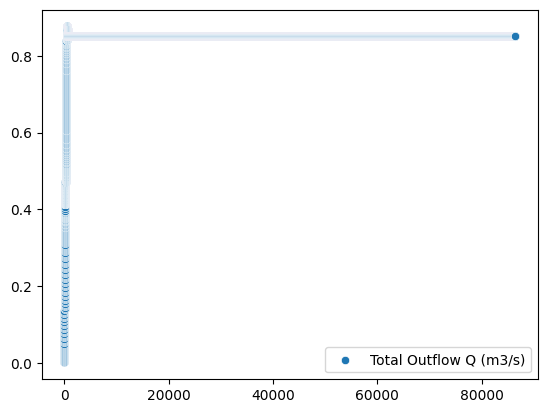

In [125]:
sns.scatterplot(Q.sum(axis=1), label='Total Outflow Q (m3/s)')

Text(0.5, 1.0, 'Spring discharge')

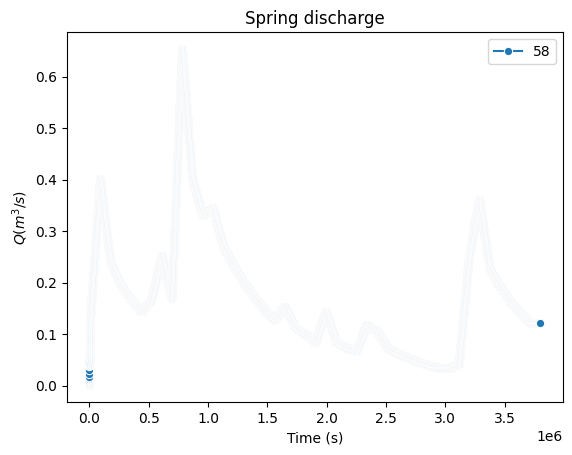

In [22]:
# label_map = {0 : 'overflow', 19 : 'bear spring'}
get_outlet_Q(Q, outflow_node_ids, edges)
outlet_Qs = get_outlet_Q(Q, outflow_node_ids, edges)
for node, spring_Q in outlet_Qs.items():
    sns.lineplot(x = t, y = spring_Q, label = node, marker = 'o')
plt.ylabel(r"$Q (m^3/s)$")
plt.xlabel("Time (s)")
plt.title("Spring discharge")

In [24]:
df= pd.DataFrame({'t (s)' : t.ravel(), 'Q (m3/s)' : outlet_Qs[64].ravel()})
df['datetime'] = t_dt = pd.to_datetime('2018-05-02') + pd.to_timedelta(t, unit='s')


KeyError: 64

In [35]:
df.to_csv('single_conduit_diffuse_and_point_recharge/spring_Q.csv', index = False)

In [29]:
bs_q_real = pd.read_csv('../../data/discharge/single_peak_05_01_2018.csv')
# bs_q_real = pd.read_csv('../../data/discharge/calibration_discharge_2018.csv')
bs_q_real['m3/s'] = bs_q_real['m3/d']/86400
bs_q_real = convert_df_to_datetime(bs_q_real, 'datetime')
bs_q_real = bs_q_real[(bs_q_real['datetime'] >= time_start) & (bs_q_real['datetime'] <= time_end)].reset_index(drop=True)

<Axes: xlabel='datetime', ylabel='m3/s'>

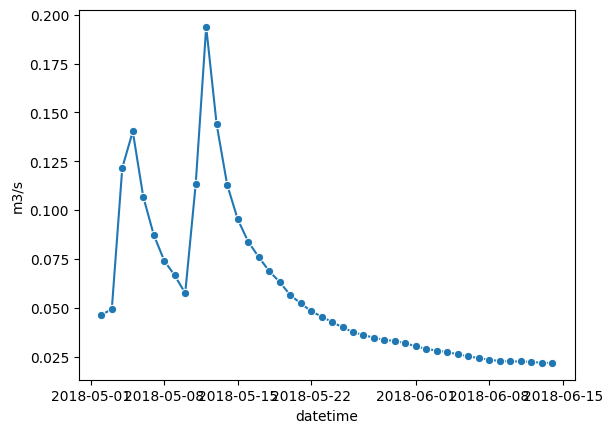

In [92]:
sns.lineplot(bs_q_real, x = 'datetime', y = 'm3/s', marker = 'o')

np.int64(58)

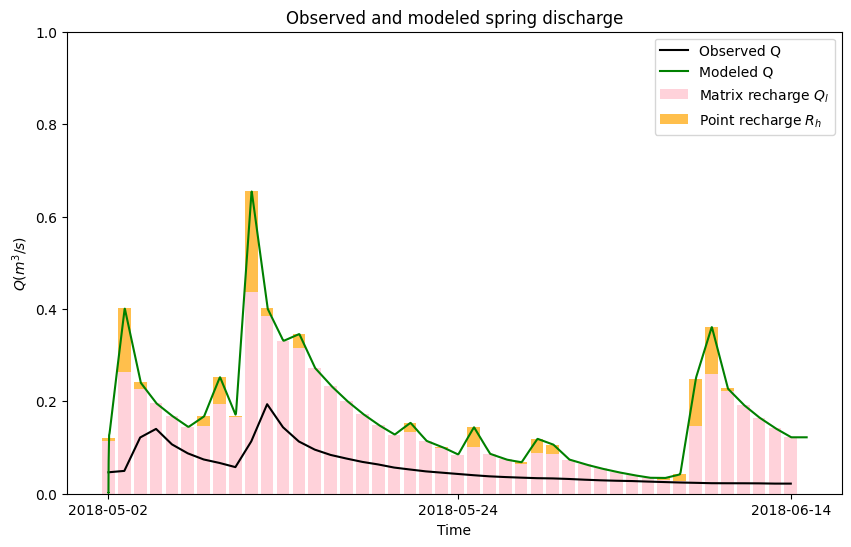

In [36]:
fig, ax = plt.subplots(figsize=(10,6))

t_dt = time_start + pd.to_timedelta(t, unit='s')
sns.lineplot(bs_q_real, x = 'datetime', y = 'm3/s', label = 'Observed Q', color = 'black')
sns.lineplot(x =t_dt , y = outlet_Qs[outflow_node_ids.iloc[0]], label = 'Modeled Q', color = 'green')
# sns.lineplot(x =t_dt , y = outlet_Qs[6], label = 'Overflow spring', color = 'green', linestyle='--')
ax.bar(rech_limited_range['date'], r_diffuse * len(diffuse_inlets), label = r'Matrix recharge $Q_l$', color = 'pink', alpha = 0.7)
ax.bar(rech_limited_range['date'], r_point * len(metadata['inlets']), bottom = r_diffuse * len(diffuse_inlets), label = r'Point recharge $R_h$', color = 'orange', alpha = 0.7)
plt.xticks([bs_q_real.datetime[0],bs_q_real.datetime[len(bs_q_real.datetime)//2], bs_q_real.datetime[len(bs_q_real.datetime)-1]])  # first, middle, last
plt.title("Observed and modeled spring discharge")
plt.ylim(0, 1)
plt.ylabel(r"$Q (m^3/s)$")
plt.xlabel("Time")
ax.legend()
# sns.lineplot(x = bs_q_real.datetime, y = Q_limited_range, label = 'recharge')

KeyError: slice(None, 30, None)

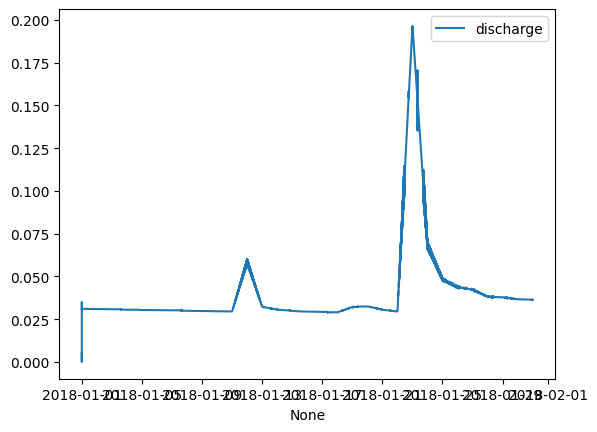

In [ ]:
sns.lineplot(x = t, y = outlet_Q, label = 'discharge')
sns.lineplot(x = bs_q_real.datetime, y = Q_per_inlet, label = 'recharge')
plt.xticks([bs_q_real.datetime[0],bs_q_real.datetime[len(bs_q_real.datetime)//2], bs_q_real.datetime[len(bs_q_real.datetime)-1]])  # first, middle, last

plt.title("openKARST recharge and discharge")

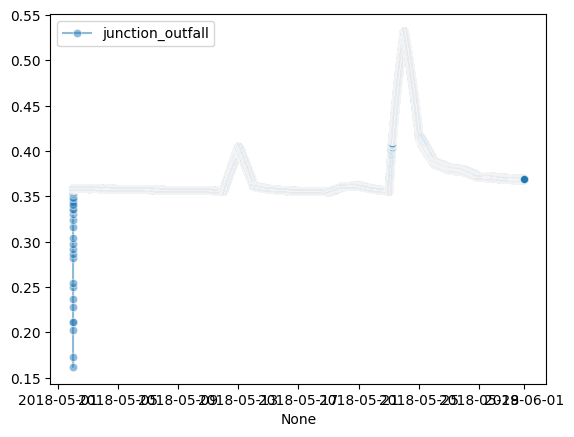

In [59]:
junction_node_ids = nodes[nodes.type=='junction_outfall'].id
for node in junction_node_ids:
    sns.lineplot(x = t, y = y[:, node], label = nodes.type[node], marker = 'o', alpha = 0.5)

In [19]:
edges['z_0'] = nodes.iloc[edges.from_id].reset_index().z
edges['z_1'] = nodes.iloc[edges.to_id].reset_index().z
edges['x_0'] = nodes.iloc[edges.from_id].reset_index().x
edges['x_1'] = nodes.iloc[edges.to_id].reset_index().x

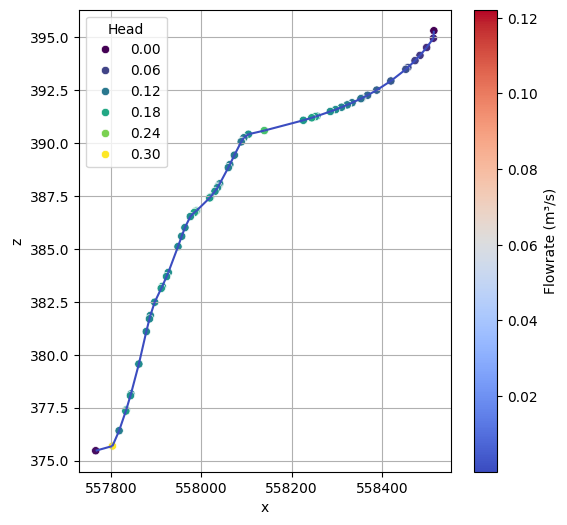

In [31]:
from matplotlib.collections import LineCollection
segments = edges[['x_0', 'z_0', 'x_1', 'z_1']].values.reshape(-1, 2, 2)
ts = len(Q)-1
# ts = 10
norm = plt.Normalize(vmin=Q[ts].min(), vmax=Q[ts].max())

# Get seaborn colormap
palette = sns.color_palette("coolwarm", as_cmap=True)

lc = LineCollection(segments, cmap=palette, norm=norm)
lc.set_array(Q[ts] * -1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(lc)
ax.autoscale()  # Needed for LineCollection to be visible
sns.scatterplot(nodes, x = 'x', y = 'z', hue = y[ts], ax = ax, palette = 'viridis')
plt.colorbar(lc, ax=ax, label="Flowrate (m³/s)")
plt.grid(True)
plt.legend(title = "Head")
# plt.title(rf"Steady state flow distibution, $Q_{{in}}$ = {Q_in}")

# plt.title(f"Steady state flow distibution, t = {np.round(t[ts], 3)}")
# plt.ylim(4.869530e6)


In [36]:
#compare different recharge conditions
results_10 = np.load('10_inlets_0/results_arrays.npz')
Q_10 = results_10['Q']
y_10 = results_10['y']
t_10 = time_start + pd.to_timedelta(results_10['t'], unit='s')
Q_out_10 = get_outlet_Q(Q_10, outflow_node_ids, edges)
in_10 = pickle.load(open('10_inlets_0/input_data.pkl', 'rb'))

In [170]:
results_5 = np.load('5_inlets_0/results_arrays.npz')
Q_5 = results_5['Q']
y_5 = results_5['y']
t_5 =  pd.to_datetime('2018-01-01') + pd.to_timedelta(results_5['t'], unit='s')
Q_out_5 = get_outlet_Q(Q_5, outflow_node_ids, edges)
in_5 = pickle.load(open('5_inlets_0/input_data.pkl', 'rb'))

In [ ]:
results_all = np.load('all_inlets_single_peak/results_arrays.npz')
Q_all = results_all['Q']
y_all = results_all['y']
t_all =  pd.to_datetime('2018-01-01') + pd.to_timedelta(results_all['t'], unit='s')
Q_out_all = get_outlet_Q(Q_all, outflow_node_ids, edges)
in_all = pickle.load(open('all_inlets_single_peak/input_data.pkl', 'rb'))

In [41]:
#compare different recharge conditions
results_1 = np.load('1_inlet_single_peak/results_arrays.npz')
Q_1 = results_1['Q']
y_1 = results_1['y']
t_1 = pd.to_datetime('2018-05-02') + pd.to_timedelta(results_1['t'], unit='s')
Q_out_1 = get_outlet_Q(Q_1, outflow_node_ids, edges)
in_1 = pickle.load(open('1_inlet_single_peak/input_data.pkl', 'rb'))

Text(0.5, 1.0, 'Discharge for Different Recharge configurations')

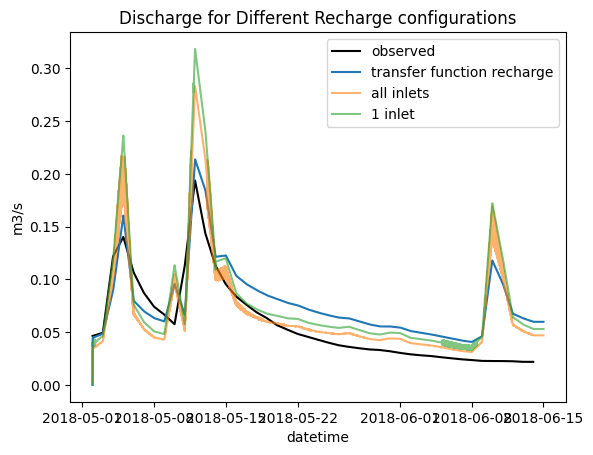

In [44]:
# sns.lineplot(x = t_10, y = Q_out_10[0] * -1, label = '10 inlets')
sns.lineplot(bs_q_real, x = 'datetime', y = 'm3/s', label = 'observed', color = 'black')
sns.lineplot(x =t_dt , y = outlet_Q, label = 'transfer function recharge')
# sns.lineplot(x = t_5, y = Q_out_5[0] * -1, label = '5 inlets')
sns.lineplot(x = t_all, y = Q_out_all[0] * -1, label = 'all inlets', alpha = 0.6)
sns.lineplot(x = t_1, y = Q_out_1[0] * -1, label = '1 inlet', alpha = 0.6)
plt.title("Discharge for Different Recharge configurations")